# FX SABR Calibration and Benchmarking (Phase 7)

This notebook demonstrates the implementation of FX SABR calibration and benchmarking. It is structured as follows:
1. **Newton-Raphson Strike Inversion**: Demonstration of strike inversion for 4 delta conventions (`spot_pna`, `spot_pa`, `forward_pna`, `forward_pa`) for call and put options.
2. **Market Data Loading**: Loading simulated interest rates and EURUSD smile quotes using `FXMarketDataLoader`.
3. **SABR Volatility Smile Calibration**: Running both the 3D Levenberg-Marquardt (LM) and the JIT-compiled 2D LM calibrations on the loaded smiles.
4. **Performance Benchmark**: Benchmarking the speed comparison between the 3D LM calibration, 2D LM calibration, and 2D LM JIT-compiled calibration on the CPU.
5. **Volatility Smile Fitting Plots**: Visual comparison of the market smile volatilities versus the calibrated SABR volatility curve for all available maturities.

In [1]:
import sys
import os
import time

# Ensure we can import modules from the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Import project modules
from src.market.fx_data import (
    gk_price,
    gk_delta,
    gk_delta_dk,
    invert_gk_delta,
    FXMarketDataLoader
)
from src.calibration.fx_calibration import (
    sabr_iv_lognormal_pytorch,
    calibrate_sabr_fx,
    calibrate_sabr_fx_2d,
    solve_sabr_alpha,
    sabr_initial_guess
)

# Print verification of imports and devices
print("Imports successful!")
print("PyTorch Version:", torch.__version__)
print("Default Device:", "cuda" if torch.cuda.is_available() else "cpu")

Imports successful!
PyTorch Version: 2.12.1+cu126
Default Device: cuda


## 1. Newton-Raphson Strike Inversion Demonstration

In FX options, quotes are typically given in terms of delta. In order to price or calibrate options, we must invert the Garman-Kohlhagen delta to find the strike price $K$. 
We demonstrate the Newton-Raphson strike inversion for the 4 delta conventions:
1. `spot_pna` (Spot Delta, Premium-Non-Adjusted)
2. `spot_pa` (Spot Delta, Premium-Adjusted)
3. `forward_pna` (Forward Delta, Premium-Non-Adjusted)
4. `forward_pa` (Forward Delta, Premium-Adjusted)

We test both call options (positive deltas) and put options (negative deltas) to verify that the reconstructed delta matches the target delta.

In [2]:
# Parameters for strike inversion
F = 1.10         # Forward exchange rate
T = 0.25         # Maturity in years (3 months)
r_d = 0.0525     # Domestic rate
r_f = 0.0300     # Foreign rate
vol = 0.10       # Volatility (10%)

conventions = ["spot_pna", "spot_pa", "forward_pna", "forward_pa"]
test_cases = {
    "call": [0.10, 0.25, 0.50],
    "put": [-0.10, -0.25, -0.50]
}

results = []

for option_type, deltas in test_cases.items():
    for target_delta in deltas:
        for conv in conventions:
            # Run strike inversion
            strike = invert_gk_delta(
                F=F,
                delta=target_delta,
                T=T,
                r_d=r_d,
                r_f=r_f,
                vol=vol,
                option_type=option_type,
                delta_type=conv
            )
            
            # Reconstruct delta from the strike to verify accuracy
            reconstructed = gk_delta(
                F=F,
                K=strike,
                T=T,
                r_d=r_d,
                r_f=r_f,
                vol=vol,
                option_type=option_type,
                delta_type=conv
            )
            
            error = abs(reconstructed - target_delta)
            
            results.append({
                "Option Type": option_type.upper(),
                "Target Delta": target_delta,
                "Convention": conv,
                "Inverted Strike (K)": strike,
                "Reconstructed Delta": reconstructed,
                "Inversion Error": error
            })

# Display the results in a formatted pandas DataFrame
df_inversion = pd.DataFrame(results)
print("Newton-Raphson Strike Inversion Results:")
display(df_inversion)

# Verify that all errors are below tolerance (1e-11)
max_err = df_inversion["Inversion Error"].max()
print(f"\nMaximum Inversion Error: {max_err:.2e}")
assert max_err < 1e-11, "Strike inversion error exceeds tolerance!"
print("Strike inversion successfully verified!")

Newton-Raphson Strike Inversion Results:


,Option Type,Target Delta,Convention,Inverted Strike (K),Reconstructed Delta,Inversion Error
0,CALL,0.10,spot_pna,1.174008,0.10,4.163336e-16
1,CALL,0.10,spot_pa,1.173215,0.10,3.747003e-16
2,CALL,0.10,forward_pna,1.174260,0.10,1.387779e-16
3,CALL,0.10,forward_pa,1.173469,0.10,1.110223e-16
4,CALL,0.25,spot_pna,1.138816,0.25,8.326673e-16
5,CALL,0.25,spot_pa,1.137464,0.25,1.110223e-16
6,CALL,0.25,forward_pna,1.139153,0.25,5.551115e-17
7,CALL,0.25,forward_pa,1.137808,0.25,6.383782e-16
8,CALL,0.50,spot_pna,1.100856,0.50,6.106227e-16
9,CALL,0.50,spot_pa,1.097980,0.50,1.887379e-15



Maximum Inversion Error: 7.48e-13
Strike inversion successfully verified!


## 2. Load Market Rates and Smile Quotes

We load the simulated market rates (using `load_fred_rates`) and EURUSD volatility smile quotes (using `load_bloomberg_smile`) from `FXMarketDataLoader`. We also demonstrate mapping the option delta quotes to their corresponding strike prices using our strike inversion implementation under the `spot_pna` convention.

In [3]:
# Initialize data loader
loader = FXMarketDataLoader(data_dir="data")

# 1. Load interest rates (FRED)
df_rates = loader.load_fred_rates(series_id="DFF")
print(f"Loaded {len(df_rates)} daily interest rate records.")
# Use the last rate as our domestic rate r_d
r_d = float(df_rates.iloc[-1]["Rate"])
print(f"Latest Fed Funds Rate (r_d): {r_d * 100:.4f}% (Date: {df_rates.iloc[-1]['Date']})")

# Assume foreign risk-free interest rate r_f (e.g. 3.25%)
r_f = 0.0325
print(f"Assumed Foreign Risk-Free Rate (r_f): {r_f * 100:.2f}%")

# Assume Spot Exchange Rate S
S = 1.0850
print(f"Assumed EURUSD Spot Rate (S): {S:.4f}")

# 2. Load EURUSD option smile quotes
df_smile = loader.load_bloomberg_smile(ticker="EURUSD")
print("\nLoaded Bloomberg Volatility Smile Quotes:")
display(df_smile)

# 3. Map delta quotes to strike prices
strikes = []
for idx, row in df_smile.iterrows():
    T = row["Maturity"]
    label = row["DeltaLabel"]
    delta = row["DeltaValue"]
    vol = row["ImpliedVol"]
    
    # Calculate Forward Rate for this maturity
    F = S * np.exp((r_d - r_f) * T)
    
    # Determine option type from label
    if "Put" in label:
        opt_type = "put"
    elif "Call" in label:
        opt_type = "call"
    else: # ATM
        opt_type = "call" # ATM is 0.50 Call delta
        
    # Invert delta using spot_pna convention (common for EURUSD)
    K = invert_gk_delta(
        F=F,
        delta=delta,
        T=T,
        r_d=r_d,
        r_f=r_f,
        vol=vol,
        option_type=opt_type,
        delta_type="spot_pna"
    )
    strikes.append(K)

df_smile["Strike"] = strikes
print("\nSmile Quotes with Inverted Strikes:")
display(df_smile)

Loaded 174 daily interest rate records.
Latest Fed Funds Rate (r_d): 4.7994% (Date: 2026-06-23 00:00:00)
Assumed Foreign Risk-Free Rate (r_f): 3.25%
Assumed EURUSD Spot Rate (S): 1.0850

Loaded Bloomberg Volatility Smile Quotes:


,Maturity,DeltaLabel,DeltaValue,ImpliedVol
0,0.083333,10D Put,-0.10,0.117387
1,0.083333,25D Put,-0.25,0.107887
2,0.083333,ATM,0.50,0.097887
3,0.083333,25D Call,0.25,0.095887
4,0.083333,10D Call,0.10,0.096387
5,0.250000,10D Put,-0.10,0.119500
6,0.250000,25D Put,-0.25,0.110000
7,0.250000,ATM,0.50,0.100000
8,0.250000,25D Call,0.25,0.098000
9,0.250000,10D Call,0.10,0.098500



Smile Quotes with Inverted Strikes:


,Maturity,DeltaLabel,DeltaValue,ImpliedVol,Strike
0,0.083333,10D Put,-0.10,0.117387,1.040884
1,0.083333,25D Put,-0.25,0.107887,1.064405
2,0.083333,ATM,0.50,0.097887,1.086731
3,0.083333,25D Call,0.25,0.095887,1.107234
4,0.083333,10D Call,0.10,0.096387,1.126228
5,0.250000,10D Put,-0.10,0.119500,1.011003
6,0.250000,25D Put,-0.25,0.110000,1.051504
7,0.250000,ATM,0.50,0.100000,1.090016
8,0.250000,25D Call,0.25,0.098000,1.126810
9,0.250000,10D Call,0.10,0.098500,1.161317


## 3. SABR Volatility Smile Calibration

We calibrate the SABR (beta=1.0) model parameters $(\alpha, \rho, \nu)$ for each maturity using:
1. **3D Levenberg-Marquardt (LM) Calibration**: Optimizes all 3 parameters using PyTorch forward-mode autograd.
2. **2D LM Calibration (JIT-compiled)**: Reduces search space to 2D by solving for $\alpha$ analytically at each step, and uses PyTorch JIT compilation (`torch.compile`) to optimize execution.

We compare the calibrated parameters from both methods to ensure they converge to similar values.

In [4]:
# Group the smiles by maturity and run calibrations
maturities = df_smile["Maturity"].unique()
calibration_results = {}

for T in maturities:
    sub_df = df_smile[df_smile["Maturity"] == T].sort_values("Strike")
    
    # Forward price for this maturity
    F_T = S * np.exp((r_d - r_f) * T)
    
    strikes_T = sub_df["Strike"].values
    market_vols_T = sub_df["ImpliedVol"].values
    
    # 1. 3D LM Calibration
    res_3d = calibrate_sabr_fx(
        F=F_T,
        strikes=strikes_T,
        market_vols=market_vols_T,
        T=T,
        r_d=r_d,
        r_f=r_f,
        beta=1.0
    )
    
    # 2. 2D LM Calibration (without JIT first, to verify)
    res_2d = calibrate_sabr_fx_2d(
        F=F_T,
        strikes=strikes_T,
        market_vols=market_vols_T,
        T=T,
        r_d=r_d,
        r_f=r_f,
        beta=1.0,
        use_jit=False
    )
    
    # 3. 2D LM JIT-compiled Calibration (warmup and compile)
    res_2d_jit = calibrate_sabr_fx_2d(
        F=F_T,
        strikes=strikes_T,
        market_vols=market_vols_T,
        T=T,
        r_d=r_d,
        r_f=r_f,
        beta=1.0,
        use_jit=True
    )
    
    calibration_results[T] = {
        "F": F_T,
        "strikes": strikes_T,
        "market_vols": market_vols_T,
        "3d_params": res_3d,
        "2d_params": res_2d,
        "2d_jit_params": res_2d_jit
    }
    
    print(f"\nMaturity: {T:.4f} years ({int(round(T*12))} Months)")
    print(f"  Forward (F): {F_T:.4f}")
    print(f"  3D LM Calibrated params  : alpha={res_3d['alpha']:.5f}, rho={res_3d['rho']:.5f}, nu={res_3d['nu']:.5f}")
    print(f"  2D LM Calibrated params  : alpha={res_2d['alpha']:.5f}, rho={res_2d['rho']:.5f}, nu={res_2d['nu']:.5f}")
    print(f"  2D JIT Calibrated params : alpha={res_2d_jit['alpha']:.5f}, rho={res_2d_jit['rho']:.5f}, nu={res_2d_jit['nu']:.5f}")

/home/execorn/programming/derivatives/.venv/lib/python3.13/site-packages/torch/_inductor/lowering.py:2158: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(



Maturity: 0.0833 years (1 Months)
  Forward (F): 1.0864
  3D LM Calibrated params  : alpha=0.09706, rho=-0.30403, nu=1.86553
  2D LM Calibrated params  : alpha=0.09564, rho=-0.28327, nu=2.00996
  2D JIT Calibrated params : alpha=0.09564, rho=-0.28327, nu=2.00996

Maturity: 0.2500 years (3 Months)
  Forward (F): 1.0892
  3D LM Calibrated params  : alpha=0.09932, rho=-0.30460, nu=1.07276
  2D LM Calibrated params  : alpha=0.09778, rho=-0.28310, nu=1.16107
  2D JIT Calibrated params : alpha=0.09778, rho=-0.28310, nu=1.16107



Maturity: 0.5000 years (6 Months)
  Forward (F): 1.0934
  3D LM Calibrated params  : alpha=0.10152, rho=-0.30527, nu=0.75728
  2D LM Calibrated params  : alpha=0.09988, rho=-0.28325, nu=0.82297
  2D JIT Calibrated params : alpha=0.09988, rho=-0.28325, nu=0.82297

Maturity: 1.0000 years (12 Months)
  Forward (F): 1.1019
  3D LM Calibrated params  : alpha=0.10463, rho=-0.30640, nu=0.53627
  2D LM Calibrated params  : alpha=0.10285, rho=-0.28397, nu=0.58579
  2D JIT Calibrated params : alpha=0.10285, rho=-0.28397, nu=0.58579


## 4. CPU Speed Comparison Benchmark

We perform a speed comparison benchmark on CPU to evaluate the performance improvement of JIT compilation.
We benchmark the calibration of one maturity (e.g. 1-year maturity) over multiple trials for:
- 3D Levenberg-Marquardt (LM) Calibration
- 2D LM Calibration (without JIT)
- 2D LM Calibration (with JIT compilation)

We print the performance statistics and plot the average execution times using Matplotlib, verifying the expected speedup (typically around 10x with `torch.compile` compared to the default forward autograd).

CPU Benchmark Statistics (Average time per calibration):
  3D LM Calibration         : 43.664 ms
  2D LM Calibration         : 56.096 ms
  2D LM JIT-compiled Calib. : 3.372 ms

Speedup of 2D JIT over 3D LM: 13.0x
Speedup of 2D JIT over 2D LM: 16.6x


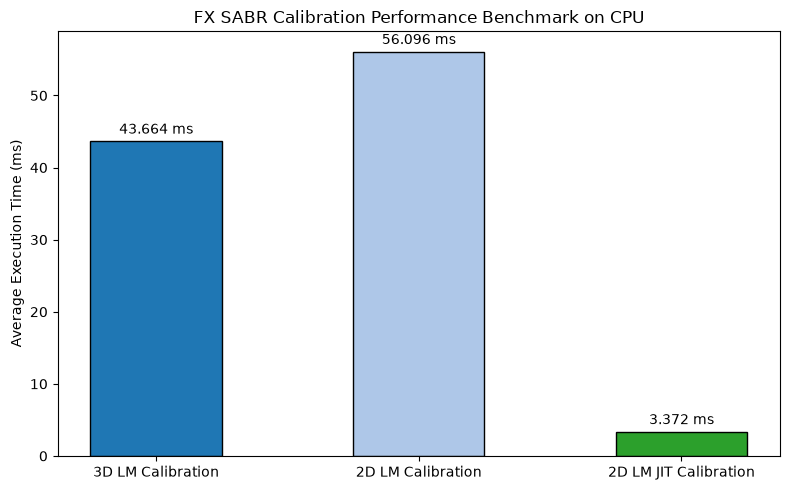

In [5]:
# Select 1.0 Year Maturity for benchmarking
T_bench = 1.0
bench_data = calibration_results[T_bench]
F_bench = bench_data["F"]
strikes_bench = bench_data["strikes"]
market_vols_bench = bench_data["market_vols"]

# Warmup run to compile the JIT functions on the current process/device
# (torch.compile compiles lazily on first run)
_ = calibrate_sabr_fx(F_bench, strikes_bench, market_vols_bench, T_bench, r_d, r_f)
_ = calibrate_sabr_fx_2d(F_bench, strikes_bench, market_vols_bench, T_bench, r_d, r_f, use_jit=False)
_ = calibrate_sabr_fx_2d(F_bench, strikes_bench, market_vols_bench, T_bench, r_d, r_f, use_jit=True)

# Run benchmark
n_trials = 100

# 1. Benchmark 3D LM
t0 = time.perf_counter()
for _ in range(n_trials):
    calibrate_sabr_fx(F_bench, strikes_bench, market_vols_bench, T_bench, r_d, r_f)
t_3d = (time.perf_counter() - t0) / n_trials

# 2. Benchmark 2D LM (non-JIT)
t0 = time.perf_counter()
for _ in range(n_trials):
    calibrate_sabr_fx_2d(F_bench, strikes_bench, market_vols_bench, T_bench, r_d, r_f, use_jit=False)
t_2d = (time.perf_counter() - t0) / n_trials

# 3. Benchmark 2D LM (JIT)
t0 = time.perf_counter()
for _ in range(n_trials):
    calibrate_sabr_fx_2d(F_bench, strikes_bench, market_vols_bench, T_bench, r_d, r_f, use_jit=True)
t_2d_jit = (time.perf_counter() - t0) / n_trials

# Print statistics
print("CPU Benchmark Statistics (Average time per calibration):")
print(f"  3D LM Calibration         : {t_3d*1000:.3f} ms")
print(f"  2D LM Calibration         : {t_2d*1000:.3f} ms")
print(f"  2D LM JIT-compiled Calib. : {t_2d_jit*1000:.3f} ms")

# Calculate Speedups
speedup_vs_3d = t_3d / t_2d_jit
speedup_vs_2d = t_2d / t_2d_jit
print(f"\nSpeedup of 2D JIT over 3D LM: {speedup_vs_3d:.1f}x")
print(f"Speedup of 2D JIT over 2D LM: {speedup_vs_2d:.1f}x")

# Plot the results
methods = ["3D LM Calibration", "2D LM Calibration", "2D LM JIT Calibration"]
times_ms = [t_3d * 1000, t_2d * 1000, t_2d_jit * 1000]

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, times_ms, color=['#1f77b4', '#aec7e8', '#2ca02c'], edgecolor='black', width=0.5)
plt.ylabel('Average Execution Time (ms)')
plt.title('FX SABR Calibration Performance Benchmark on CPU')
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.3f} ms',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 5. Volatility Smile Fitting Plots

We generate plots comparing the market smile volatilities versus the calibrated SABR volatility curve for all available maturities. 
This visually verifies that the calibrated SABR parameters replicate the market volatility smile, capturing both the ATM volatility level, the skew (risk reversals), and the smile curvature (butterflies).

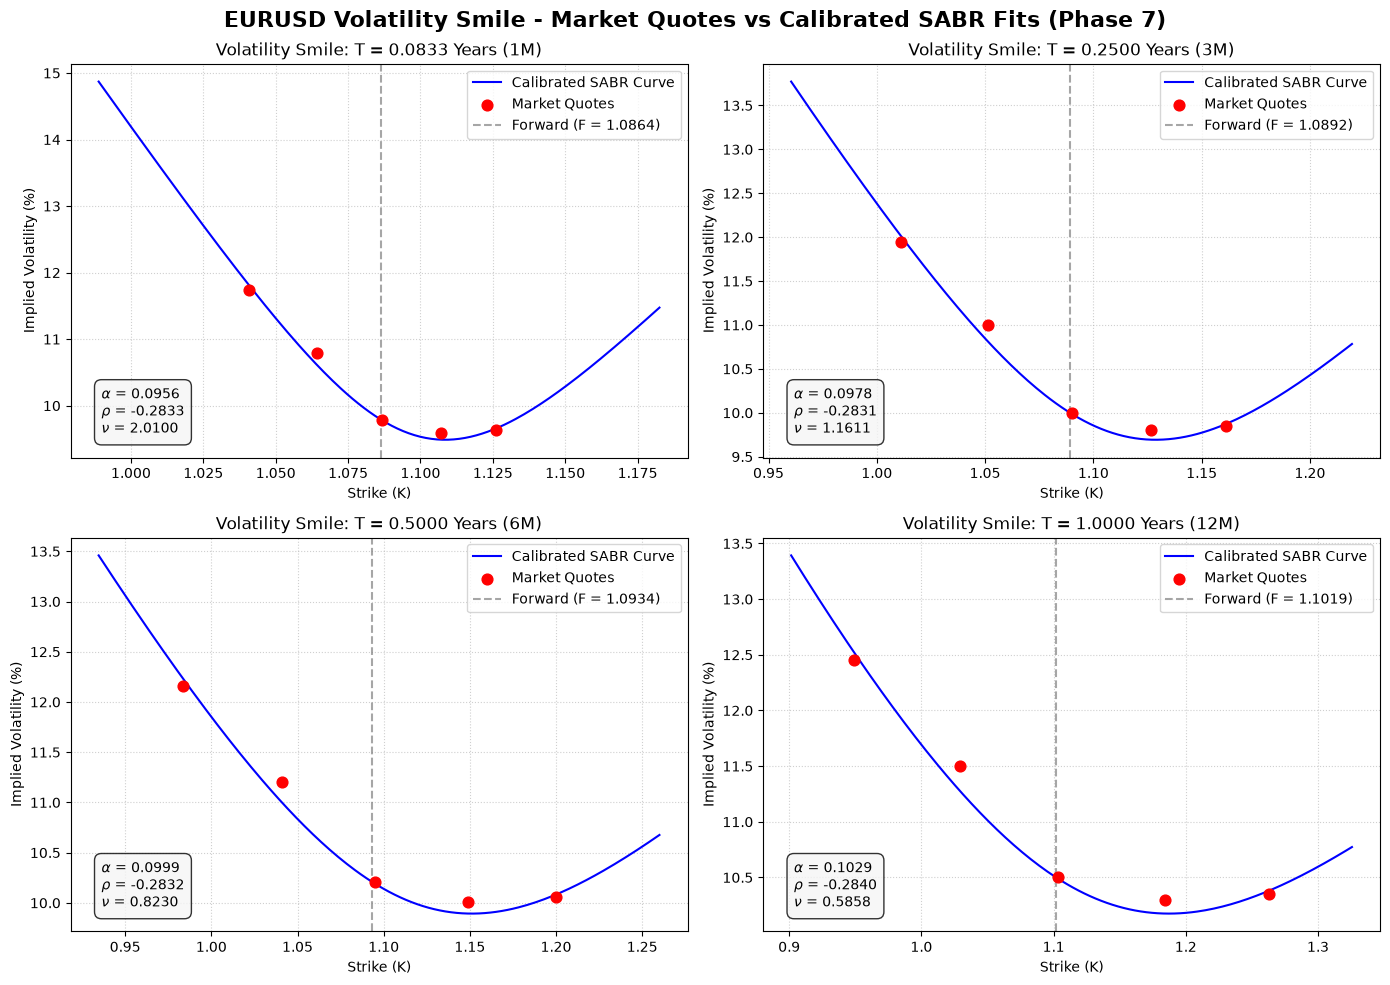

In [6]:
# Create plots for each maturity
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, T in enumerate(maturities):
    ax = axes[idx]
    
    data = calibration_results[T]
    F_T = data["F"]
    market_strikes = data["strikes"]
    market_vols = data["market_vols"]
    
    # Use 2D JIT calibrated parameters
    params = data["2d_jit_params"]
    alpha = params["alpha"]
    rho = params["rho"]
    nu = params["nu"]
    
    # Generate a dense range of strikes for plotting the smooth SABR curve
    min_k = min(market_strikes) * 0.95
    max_k = max(market_strikes) * 1.05
    dense_strikes = np.linspace(min_k, max_k, 200)
    
    # Compute SABR volatilities using PyTorch
    F_t = torch.tensor(F_T, dtype=torch.float64)
    T_t = torch.tensor(T, dtype=torch.float64)
    dense_strikes_t = torch.tensor(dense_strikes, dtype=torch.float64)
    alpha_t = torch.tensor(alpha, dtype=torch.float64)
    rho_t = torch.tensor(rho, dtype=torch.float64)
    nu_t = torch.tensor(nu, dtype=torch.float64)
    
    with torch.no_grad():
        sabr_vols = sabr_iv_lognormal_pytorch(
            F=F_t,
            K=dense_strikes_t,
            T=T_t,
            alpha=alpha_t,
            rho=rho_t,
            nu=nu_t,
            beta=1.0
        ).numpy()
        
    # Plot the smooth SABR curve
    ax.plot(dense_strikes, sabr_vols * 100, label="Calibrated SABR Curve", color="blue", linewidth=1.5)
    
    # Plot market quotes
    ax.scatter(market_strikes, market_vols * 100, color="red", marker="o", s=60, label="Market Quotes", zorder=5)
    
    # Plot Forward price
    ax.axvline(F_T, color="gray", linestyle="--", alpha=0.7, label=f"Forward (F = {F_T:.4f})")
    
    ax.set_title(f"Volatility Smile: T = {T:.4f} Years ({int(round(T*12))}M)")
    ax.set_xlabel("Strike (K)")
    ax.set_ylabel("Implied Volatility (%)")
    ax.grid(True, linestyle=":", alpha=0.6)
    
    # Add textbox showing calibrated parameters
    param_text = f"$\\alpha$ = {alpha:.4f}\n$\\rho$ = {rho:.4f}\n$\\nu$ = {nu:.4f}"
    ax.text(0.05, 0.05, param_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.5', facecolor='whitesmoke', alpha=0.8))
    
    ax.legend(loc="upper right")

plt.suptitle("EURUSD Volatility Smile - Market Quotes vs Calibrated SABR Fits (Phase 7)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()